In [47]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [48]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

In [49]:
def dilatasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2

    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):

            if image[i, j] == 255:

                for k in range(k_height):
                    for l in range(k_width):

                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255

            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil

In [50]:
def erosi(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape

    center_y = k_height // 2
    center_x = k_width // 2

    hasil = np.zeros((img_height, img_width), dtype=np.uint8)

    for i in range(center_y, img_height - center_y):
        for j in range(center_x, img_width - center_x):

            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1:
                        img_y = i + k - center_y
                        img_x = j + l - center_x

                        if image[img_y, img_x] == 0:
                            cocok = False
                            break
                if not cocok:
                    break

            if cocok:
                hasil[i, j] = 255

    return hasil

In [51]:
def thinning(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

        hapus = []

        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

In [52]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)

    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

In [53]:
def thickening(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = dilatasi(hasil, kernel)
    return hasil

In [67]:
# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

In [55]:
def konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size//2
    padded = np.pad(img, pad_size, mode = 'constant')
    
    canvas = np.zeros_like(img).astype(np.float32)
    h, w = img.shape
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            canvas [i, j] = np.sum(region * kernel)
            
    return canvas

In [56]:
def edge(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = konvolusi(img, kernelx)
    gy = konvolusi(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

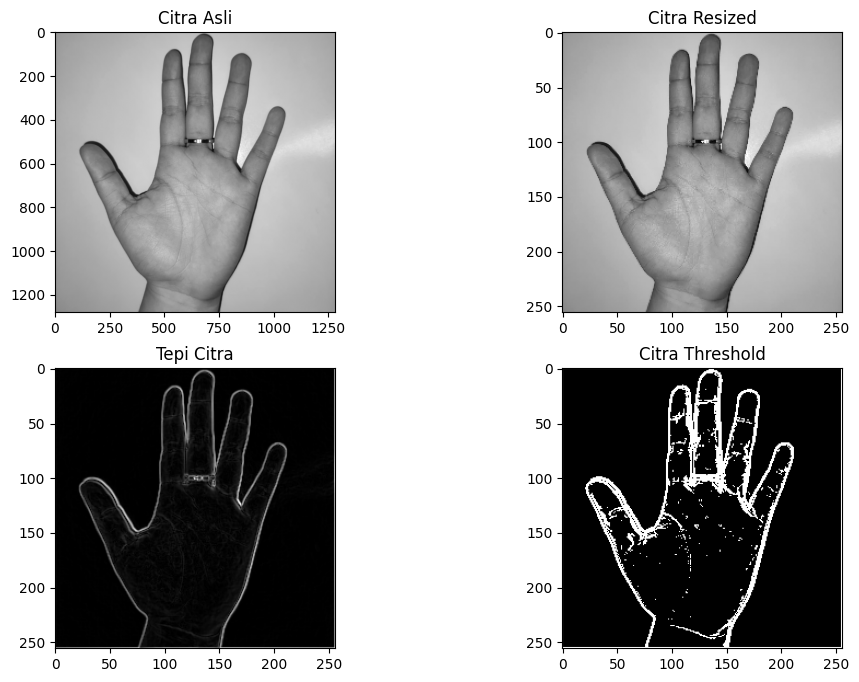

In [57]:
citraTanganAsli = cv.imread('assets/telapakTangan.jpeg', cv.IMREAD_GRAYSCALE)
citraTanganResized = resize(citraTanganAsli, 256, 256)

tepiTangan = edge(citraTanganResized, sobelx, sobely)
citraTanganThreshold = thresholding(tepiTangan, 20)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(citraTanganAsli, cmap='gray')
plt.title('Citra Asli')

plt.subplot(2,2,2)
plt.imshow(citraTanganResized, cmap='gray')
plt.title('Citra Resized')

plt.subplot(2,2,3)
plt.imshow(tepiTangan, cmap='gray')
plt.title('Tepi Citra')

plt.subplot(2,2,4)
plt.imshow(citraTanganThreshold, cmap='gray')
plt.title('Citra Threshold')

plt.show()


In [58]:
kernel_diamond = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
])
kernel_cross = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])
kernel_x = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
], dtype=np.uint8)

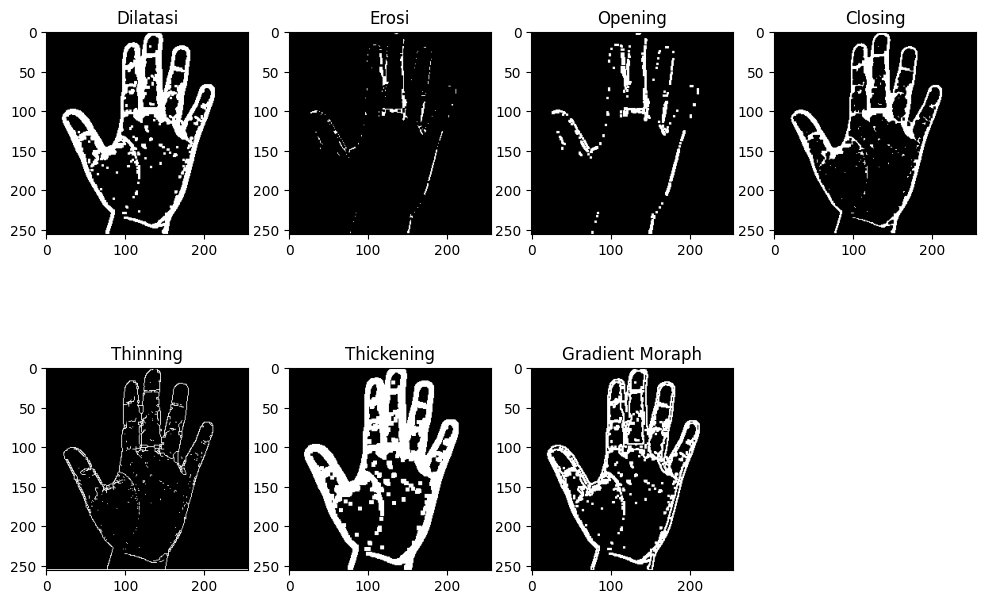

In [59]:
citraTanganDilatasi = dilatasi(citraTanganThreshold, kernel_cross)
citraTanganErosi = erosi(citraTanganThreshold, kernel_cross)
citraTanganOpening = dilatasi(erosi(citraTanganThreshold, kernel_cross), kernel_cross)
citraTanganClosing = erosi(dilatasi(citraTanganThreshold, kernel_cross), kernel_cross)
citraTanganThinning = thinning(citraTanganThreshold)
citraTanganThickening = thickening(citraTanganThreshold, kernel_cross, iterasi = 2)
citraTanganGradientMoraph = np.clip(
    citraTanganDilatasi.astype(np.int32) - citraTanganErosi.astype(np.int32),
    0, 255
).astype(np.uint8)

plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.imshow(citraTanganDilatasi, cmap='gray')
plt.title('Dilatasi')

plt.subplot(2,4,2)
plt.imshow(citraTanganErosi, cmap='gray')
plt.title('Erosi')

plt.subplot(2,4,3)
plt.imshow(citraTanganOpening, cmap='gray')
plt.title('Opening')

plt.subplot(2,4,4)
plt.imshow(citraTanganClosing, cmap='gray')
plt.title('Closing')

plt.subplot(2,4,5)
plt.imshow(citraTanganThinning, cmap='gray')
plt.title('Thinning')

plt.subplot(2,4,6)
plt.imshow(citraTanganThickening, cmap='gray')
plt.title('Thickening')

plt.subplot(2,4,7)
plt.imshow(citraTanganGradientMoraph, cmap='gray')
plt.title('Gradient Moraph')

plt.show()


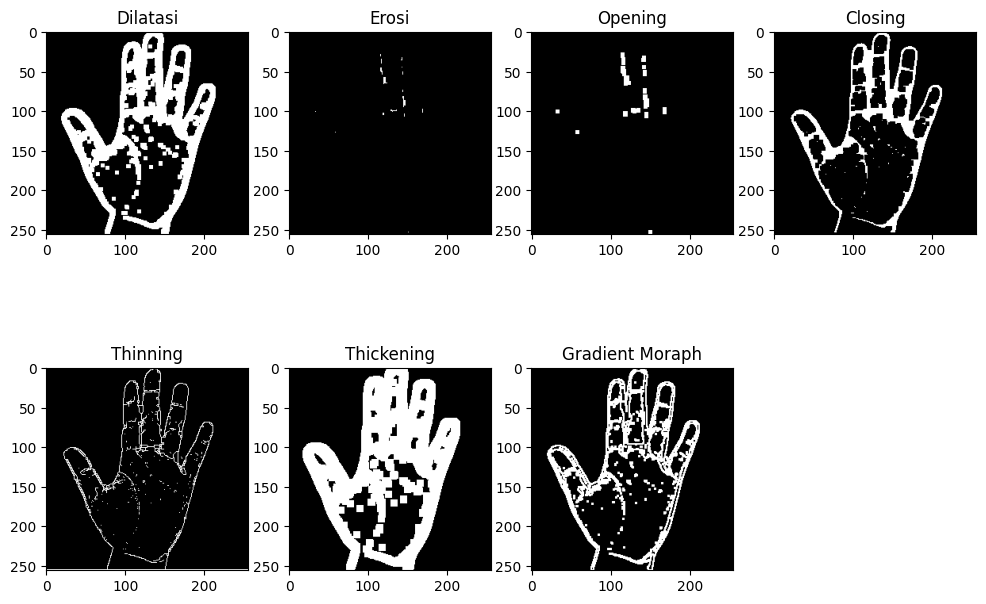

In [60]:
citraTanganDilatasi2 = dilatasi(citraTanganThreshold, kernel_diamond)
citraTanganErosi2 = erosi(citraTanganThreshold, kernel_diamond)
citraTanganOpening2 = dilatasi(erosi(citraTanganThreshold, kernel_diamond), kernel_diamond)
citraTanganClosing2 = erosi(dilatasi(citraTanganThreshold, kernel_diamond), kernel_diamond)
citraTanganThinning2 = thinning(citraTanganThreshold)
citraTanganThickening2 = thickening(citraTanganThreshold, kernel_diamond, iterasi = 2)
citraTanganGradientMoraph2 = np.clip(
    citraTanganDilatasi.astype(np.int32) - citraTanganErosi.astype(np.int32),
    0, 255
).astype(np.uint8)

plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.imshow(citraTanganDilatasi2, cmap='gray')
plt.title('Dilatasi')

plt.subplot(2,4,2)
plt.imshow(citraTanganErosi2, cmap='gray')
plt.title('Erosi')

plt.subplot(2,4,3)
plt.imshow(citraTanganOpening2, cmap='gray')
plt.title('Opening')

plt.subplot(2,4,4)
plt.imshow(citraTanganClosing2, cmap='gray')
plt.title('Closing')

plt.subplot(2,4,5)
plt.imshow(citraTanganThinning2, cmap='gray')
plt.title('Thinning')

plt.subplot(2,4,6)
plt.imshow(citraTanganThickening2, cmap='gray')
plt.title('Thickening')

plt.subplot(2,4,7)
plt.imshow(citraTanganGradientMoraph2, cmap='gray')
plt.title('Gradient Moraph')

plt.show()

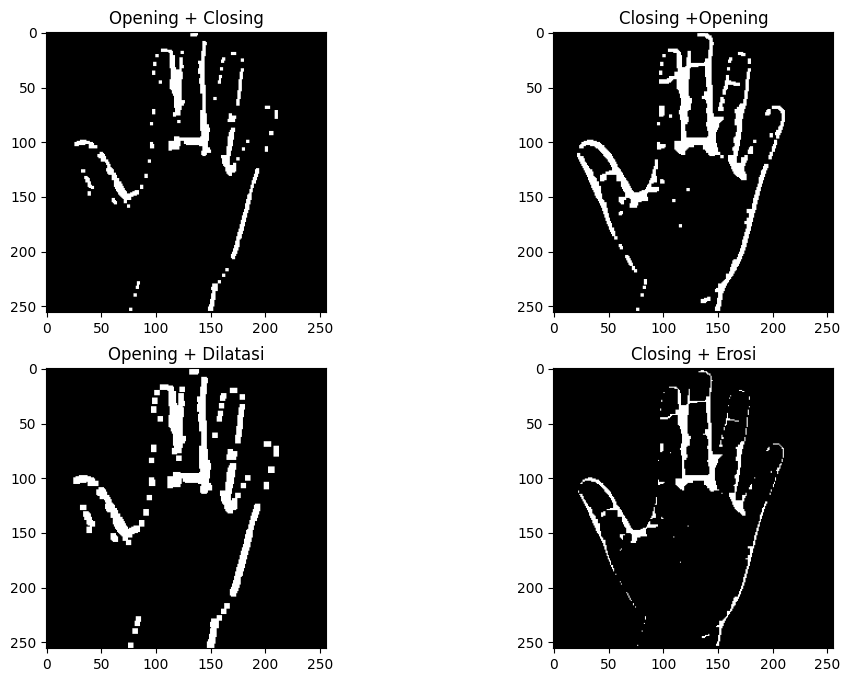

In [61]:
opening_closing = erosi(dilatasi(citraTanganOpening, kernel_cross), kernel_cross)
closing_opening = dilatasi(erosi(citraTanganClosing, kernel_cross), kernel_cross)
opening_dilasi = dilatasi(citraTanganOpening, kernel_cross)
closing_erosi = erosi(citraTanganClosing, kernel_cross)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(opening_closing, cmap='gray')
plt.title('Opening + Closing')

plt.subplot(2,2,2)
plt.imshow(closing_opening, cmap='gray')
plt.title('Closing +Opening')

plt.subplot(2,2,3)
plt.imshow(opening_dilasi, cmap='gray') 
plt.title('Opening + Dilatasi')

plt.subplot(2,2,4)
plt.imshow(closing_erosi, cmap='gray')
plt.title('Closing + Erosi')

plt.show()


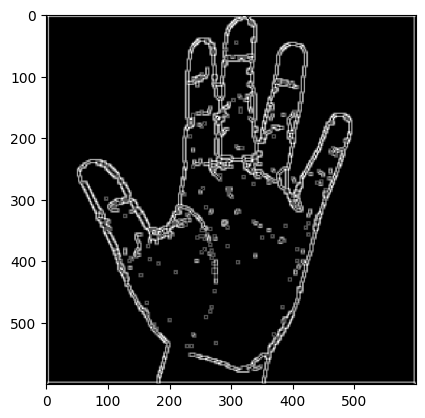

In [72]:
eksplorasi = edge(citraTanganThinning, sobelx, sobely)
eks_resize = resize(eksplorasi, 600, 600)

plt.imshow(eks_resize, cmap='gray')
plt.show()